# archiveWinston

### Modules

In [1]:
from obspy import UTCDateTime
import obspy
from obspy.clients.fdsn import Client
from obspy.clients.earthworm import Client as EWClient
from obspy.clients.seedlink import Client as SeedLinkClient
from obspy.core.trace import Trace
from obspy.core.stream import Stream
from obspy.signal.trigger import coincidence_trigger
import numpy as np
from numpy import dtype
from scipy import stats
from scipy.fftpack import fft
import glob, os, itertools

In [2]:
import timeutils
import seismology.stream
import seismology.stream.datasource
from seismology.stream.datasource import createClient
from seismology.stream.nslcobject import str2nslc
from seismology.stream import removeWinstonGaps

In [3]:
def write2filestructure( st, basedir='./',
                    filestructure='BASEDIR/YEAR/NET/STA/CHAN.TYPE/NET.STA.LOC.CHAN.TYPE.YEAR.DAY.EXTENSION',
                    format='mseed'):
    
    import os
    from pathlib import Path

    network = st[0].stats.network
    station = st[0].stats.station
    location = st[0].stats.location
    channel = st[0].stats.channel

    datatype = 'D'

    year = str(st[0].stats.starttime.year)
    day  = str(st[0].stats.starttime.julday)
    month = str(st[0].stats.starttime.month)
    date = str(st[0].stats.starttime.day)
    hour = str(st[0].stats.starttime.hour)
    minute = str(st[0].stats.starttime.minute)
    second = str(st[0].stats.starttime.second)
    
    filestructure = filestructure.replace('BASEDIR', basedir)

    filestructure = filestructure.replace('NET', network)
    filestructure = filestructure.replace('STA', station)
    filestructure = filestructure.replace('LOC', location)
    filestructure = filestructure.replace('CHAN', channel)
    filestructure = filestructure.replace('TYPE', datatype)


    filestructure = filestructure.replace('YEAR', year)
    filestructure = filestructure.replace('MONTH', month)
    filestructure = filestructure.replace('DATE', date)
    filestructure = filestructure.replace('DAY', day)

    filestructure = filestructure.replace('HOUR', hour)
    filestructure = filestructure.replace('MINUTE', minute)
    filestructure = filestructure.replace('SECOND', second)

    filestructure = filestructure.replace('EXTENSION', format)
    
    filestructure = os.path.normcase(os.path.normpath(filestructure))
    
    # Create all necessary directories
    filestructure = os.path.abspath(filestructure)
    directories, filename = os.path.split(filestructure)
    Path(directories).mkdir(parents=True, exist_ok=True)
    
    st.write(filestructure)
    
    return filestructure


In [4]:
#nslc_list = 'VG.PSAG.00.EHZ'
#type(nslc_list) is str

### Input Parameters

In [5]:
#server        = 'vdap.org'            # str : waveserver IP
#port          = 16024                 # int : waveserver port
ds             = 'wws:vdap.org:16024'  # str : file:/file/structure/ or wws:waveserverip:port

nslc_list     = ['VG.PSAG.00.EHZ']    # list or str : Stations to download (a single station may be entered as a str)
nslc_order    = 'nslc'                # str : Station code order : 'NSLC', 'SCNL', 'SCN'
nslc_out_list = ['VG.PSAG.01.EHZ']    # list or str : Replacement station code for output files

tstart        = '2017/09/18 11:02:06' # date format understood by ObsPy
tend          = '2017/09/18 11:03:46' # date format understand by ObsPy
tstart        = '2017/09/18 00:00:00' # date format understood by ObsPy
tend          = '2017/09/20 00:00:00' # date format understand by ObsPy

nsec          = 3600                  # int : Maximum amount of time to download at once (seconds)
nsecproc      = 86400                 # int : Maximum amount of time to process at once (seconds)

removeWWSgaps = True                  # bool : If True, removes -2**31 from all traces. Warning, False may cause errors when reading from WWS
verbose       = True

In [6]:
i=0
while i==0:

    # Establish datasource
    if verbose: print('>>> Loading data from {}'.format(ds))
    client = createClient(ds)
    
    # Assert NSLC as list
    if type(nslc_list) is str: nslc_list = [nslc_list]

    # Assert tstart, tend as UTCDateTime
    tstart = UTCDateTime(tstart)
    tend = UTCDateTime(tend)
    
    if nslc_out_list is None:
        changenslc=False
        nslc_out_list = nslc_list
    else:
        changenslc=True

    
    # Loop through list of NSLCs
    for nslc, nslc_out in zip(nslc_list, nslc_out_list):
        
        if verbose: print('>>> Station {}'.format(nslc))
        #network, station, channel, location = str2NSLC( nslc )
        
        # Loop through time chunks for output file
        proctstarts, proctends = timeutils.createTimeChunks(tstart, tend, nsec=nsecproc, verbose=False)
        for pt1, pt2 in zip(proctstarts, proctends):
            st = Stream()
            print('>>> Prepping data for file storage from {} to {}'.format(pt1, pt2))
        
            # Create smaller time chunks to download, if necessary
            dtstarts, dtends = timeutils.createTimeChunks(pt1, pt2, nsec=nsec, verbose=False)
            for dt1, dt2 in zip(dtstarts, dtends):
                if verbose: print('>>> Downloading data from {} to {}'.format(dt1, dt2))

                #try:
                for i in range(len([0])):
                    net, sta, loc, cha = str2nslc(nslc)
                    stmp = client.get_waveforms(net, sta, loc, cha, dt1, dt2)
                    
                    # Clean Data
                    stmp = removeWinstonGaps(stmp) # Loops through Streams
                    #for m in range(len(stmp)):
                    #    stmp[m] = stmp[m].detrend('demean')
                    #stmp = stmp.merge(method=1, fill_value=0)
                    #for m in range(len(stmp)):
                    #    stmp[m].data.dtype.name='int32'
                    #    stmp[m].data=stmp[m].data.astype('int32')
                    for m in range(len(stmp)):
                        print('Checking for data type')
                    #    # deal with error when sub-traces have different dtypes
                        if stmp[m].data.dtype.name != 'int32':
                            print('Changing dtype to int32 (A)')
                            stmp[m].data=stmp[m].data.astype('int32')
                        if stmp[m].data.dtype!=dtype('int32'):
                            print('Changing dtype to int32 (B)')
                            stmp[m].data=stmp[m].data.astype('int32')
                    #    # deal with rare error when sub-traces have different sample rates
                        if stmp[m].stats.sampling_rate!=round(stmp[m].stats.sampling_rate):
                            stmp[m].stats.sampling_rate=round(stmp[m].stats.sampling_rate)
                        stmp[m] = stmp[m].resample(100)
                #except:
                #    print('>>> ! Error occurred downloading data.')
                #    stmp = Stream()

                st += stmp

            st = st.merge(method=1, fill_value=0)

            if changenslc:
                print(nslc_out)
                net, sta, loc, cha = str2nslc(nslc_out)
                st[0].stats.network  = net
                st[0].stats.station  = sta
                st[0].stats.location = loc
                st[0].stats.channel  = cha

            # Write Stream to File
            print(st)
            f = write2filestructure(st, basedir='/Users/jjw2/Downloads')
            print('>>> Wrote file {}'.format(f))

    i+=1

>>> Loading data from wws:vdap.org:16024
>>> Station VG.PSAG.00.EHZ
>>> Prepping data for file storage from 2017-09-18T00:00:00.000000Z to 2017-09-19T00:00:00.000000Z
>>> Downloading data from 2017-09-18T00:00:00.000000Z to 2017-09-18T01:00:00.000000Z
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for data type
Checking for

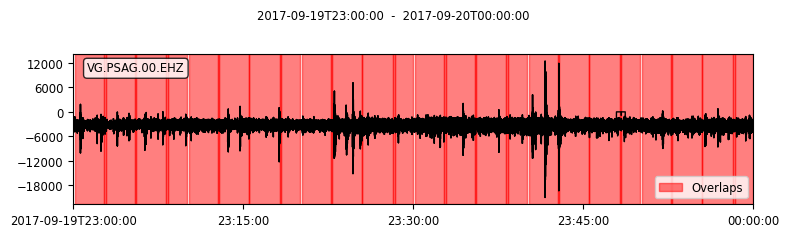

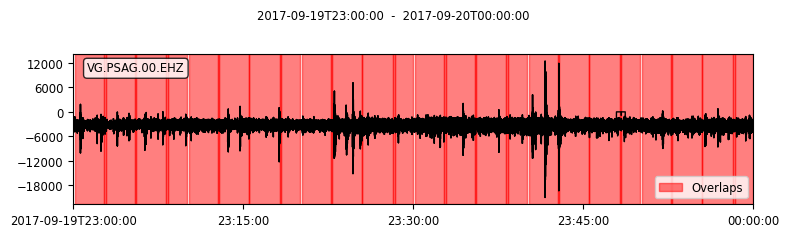

In [7]:
stmp.plot()

In [8]:
st

1 Trace(s) in Stream:
VG.PSAG.01.EHZ | 2017-09-19T00:00:00.000000Z - 2017-09-20T00:00:00.000000Z | 100.0 Hz, 8640001 samples

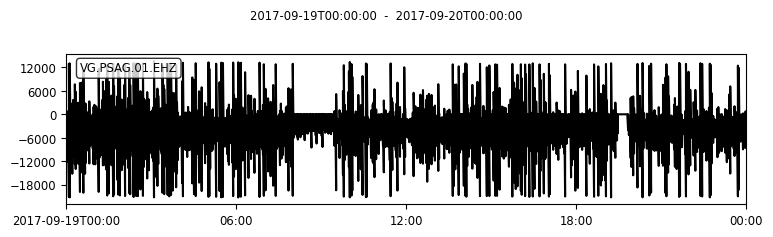

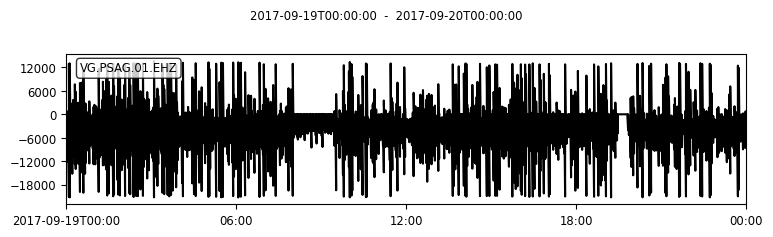

In [9]:
st.plot()

In [10]:
st[0].stats

         network: VG
         station: PSAG
        location: 01
         channel: EHZ
       starttime: 2017-09-19T00:00:00.000000Z
         endtime: 2017-09-20T00:00:00.000000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 8640001
           calib: 1.0
      processing: ['ObsPy 1.2.2: trim(endtime=UTCDateTime(2017, 9, 19, 1, 0)::fill_value=None::nearest_sample=True::pad=False::starttime=UTCDateTime(2017, 9, 19, 0, 0))', "ObsPy 1.2.2: resample(no_filter=True::sampling_rate=100::strict_length=False::window='hanning')"]

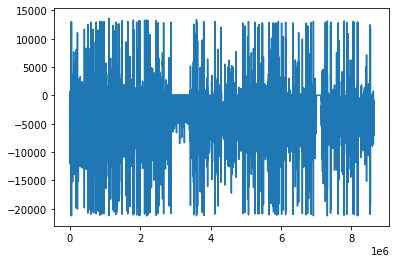

In [11]:
import matplotlib.pyplot as plt
plt.plot(st[0].data)

In [12]:
j=2
stmp[j].data.dtype

dtype('float64')

In [13]:
j
if stmp[j].data.dtype.name != 'int32':
    stmp[j].data=stmp[j].data.astype('int32')
if stmp[j].data.dtype!=dtype('int32'):
    stmp[j].data=stmp[j].data.astype('int32')
# deal with rare error when sub-traces have different sample rates
if stmp[j].stats.sampling_rate!=round(stmp[j].stats.sampling_rate):
    stmp[j].stats.sampling_rate=round(stmp[j].stats.sampling_rate)

In [14]:
stmp[j].data.dtype

dtype('int32')

In [15]:
st[0].data.dtype

dtype('float64')

In [16]:
from obspy import read
st2 = read('/Users/jjw2/Downloads/2017/VG/PSAG/EHZ.D/VG.PSAG.01.EHZ.D.2017.261.mseed')

In [17]:
st2

1 Trace(s) in Stream:
VG.PSAG.01.EHZ | 2017-09-18T00:00:00.000000Z - 2017-09-19T00:00:00.000000Z | 100.0 Hz, 8640001 samples

In [18]:
st2[0].stats

         network: VG
         station: PSAG
        location: 01
         channel: EHZ
       starttime: 2017-09-18T00:00:00.000000Z
         endtime: 2017-09-19T00:00:00.000000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 8640001
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 17109, 'encoding': 'FLOAT64', 'byteorder': '>', 'record_length': 4096, 'filesize': 70078464})

In [19]:
st2[0].data = st2[0].data.astype('int32')

In [20]:
st2[0].stats

         network: VG
         station: PSAG
        location: 01
         channel: EHZ
       starttime: 2017-09-18T00:00:00.000000Z
         endtime: 2017-09-19T00:00:00.000000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 8640001
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 17109, 'encoding': 'FLOAT64', 'byteorder': '>', 'record_length': 4096, 'filesize': 70078464})

In [21]:
type(st2[0].data[0])

numpy.int32

In [22]:
st2[0].stats.mseed['encoding'] = 'int32'

In [23]:
st2[0].stats

         network: VG
         station: PSAG
        location: 01
         channel: EHZ
       starttime: 2017-09-18T00:00:00.000000Z
         endtime: 2017-09-19T00:00:00.000000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 8640001
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 17109, 'encoding': 'int32', 'byteorder': '>', 'record_length': 4096, 'filesize': 70078464})

In [24]:
st2[0].data[0]

-3806

In [25]:
st2[0].data = st2[0].data[:-1]
st2

1 Trace(s) in Stream:
VG.PSAG.01.EHZ | 2017-09-18T00:00:00.000000Z - 2017-09-18T23:59:59.990000Z | 100.0 Hz, 8640000 samples

In [26]:
st2[0].stats

         network: VG
         station: PSAG
        location: 01
         channel: EHZ
       starttime: 2017-09-18T00:00:00.000000Z
         endtime: 2017-09-18T23:59:59.990000Z
   sampling_rate: 100.0
           delta: 0.01
            npts: 8640000
           calib: 1.0
         _format: MSEED
           mseed: AttribDict({'dataquality': 'D', 'number_of_records': 17109, 'encoding': 'int32', 'byteorder': '>', 'record_length': 4096, 'filesize': 70078464})